# SENSE noise-level testbench

Does `physics/sense_noise.py` actually predict the noise in a SENSE reconstruction?

The plan is the obvious one: reconstruct, look at the residual, and divide by the
predicted noise-level map. If the map is right the residual goes from *spatially
structured* to *flat and unit-variance*. Two things have to be got right for that
to be a real test rather than a vacuous one, and both are easy to get wrong:

**1. The residual has to be noise-only.** `x_hat - x_true` is dominated by
*reconstruction bias* -- residual aliasing, ESPIRiT map error, Tikhonov shrinkage --
none of which is noise and none of which `sense_noise_level` claims to describe. The
quantity the theory is about is

$$ r = \hat{x}(y + \xi) - \hat{x}(y) $$

which for a linear reconstruction equals $\hat{x}(\xi)$ exactly. Section 1 checks
that identity numerically; if your reconstruction is nonlinear (regularized,
learned) the difference form is the one that still means something, and what you
measure is the local linearisation.

**2. "White" means flat *variance*, not zero *correlation*.** Dividing by the
noise-level map removes the spatially varying noise *power*. It cannot remove
spatial correlation, and SENSE has plenty: without ACS the covariance is supported
*exactly* on the aliasing lattice, so the normalized residual keeps $A-1$ nonzero
correlations per pixel at PE offsets $\pm j\,N_\text{PE}/A$. Section 5 measures
those spikes and shows they sit where the theory says. Seeing them is a *pass*, not
a failure -- expecting a pure delta autocorrelation here means you would reject a
correct map.

**What to divide by.** The noise-level map $\sigma$, not the g-factor. $g$ is
dimensionless and already divided by $\sqrt{A_\text{eff}}\,\sigma_\text{full}$, so
`r / g` still carries the $\sigma_\text{full}$ shape. Those two differ only when the
maps are not exactly unit-RSS -- which is exactly the case for real ESPIRiT maps.
Section 3 shows both so you can see the gap.

**Regimes.** Three, in increasing order of how much the theory is approximating:

| mask | pinv | status |
|---|---|---|
| uniform, no ACS | plain | **exact** -- `block_sense` is precisely the estimator the formula describes |
| uniform, no ACS | weighted | **exact** -- CG-SENSE on whitened data |
| uniform **+ ACS** | weighted | **approximate** -- the delta-for-sinc bracket, expected to be a few % optimistic |

The third is what `make_acc_mask` produces by default, so it is the one that
matters in practice. It should *not* come out at ratio 1.000, and Section 6
quantifies by how much.

In [13]:
import os
os.chdir('/scratch/ee2178/ImMAP')

import math

import matplotlib.pyplot as plt
import numpy as np
import torch

from operators.fourier import fftc, ifftc
from physics.gfactor import (
    cg_sense, local_noise_std, sample_kspace_noise, sigma_full_map, support_mask,
)
from physics.mask import make_acc_mask
from physics.sense_noise import (
    block_sense, coil_combined_noise_level, effective_acceleration,
    sense_gfactor, sense_noise_level,
)

# 'phantom' is self-contained (no data, runs on CPU); 'fastmri' uses the real maps.
SOURCE = 'fastmri'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
DT = torch.complex64

torch.manual_seed(0)
print(f"source={SOURCE}  device={device}")

source=fastmri  device=cuda


## 0) Data

The phantom path exists so this notebook is runnable anywhere and so the *maps are
exactly what we think they are*: unit-RSS on a known support, zero outside. Real
ESPIRiT maps are only approximately unit-RSS, which is itself worth seeing -- run
both and compare Section 6's tables.

In [2]:
def ellipse_phantom(H, W, device='cpu'):
    yy = torch.linspace(-1, 1, H, device=device)[:, None]
    xx = torch.linspace(-1, 1, W, device=device)[None, :]
    img = torch.zeros(H, W, device=device)
    for cy, cx, ry, rx, val in [(0, 0, .85, .70, 1.0), (-.10, 0, .55, .45, .55),
                                (.25, -.30, .18, .12, 1.3), (-.35, .28, .22, .15, .25)]:
        inside = ((yy - cy) / ry) ** 2 + ((xx - cx) / rx) ** 2 <= 1.0
        img = torch.where(inside, torch.full_like(img, val), img)
    return img


def birdcage_maps(C, H, W, device='cpu', radius=1.35):
    '''C smooth coil profiles from ring-mounted elements: 1/r falloff x phase ramp.'''
    yy = torch.linspace(-1, 1, H, device=device)[:, None]
    xx = torch.linspace(-1, 1, W, device=device)[None, :]
    out = []
    for c in range(C):
        th = 2 * math.pi * c / C
        py, px = radius * math.cos(th), radius * math.sin(th)
        amp = 1.0 / ((yy - py) ** 2 + (xx - px) ** 2 + 0.25)
        out.append(amp * torch.exp(1j * 2.2 * (yy * py + xx * px)))
    return torch.stack(out).to(DT)[None]


def make_phantom(C=8, H=96, W=96, device='cpu'):
    '''Returns (x_true, smaps): unit-RSS maps inside the object, zero outside.

    W = 96 because the whole closed form needs `accel | W`: 96 covers A = 2, 3, 4,
    6. (128 would silently exclude A = 3, and fastMRI's 320/368 exclude it too --
    the sweep in Section 6 filters on divisibility rather than pretending.)
    '''
    obj = ellipse_phantom(H, W, device)
    body = (obj > 0)[None, None]
    s = birdcage_maps(C, H, W, device)
    s = torch.where(body, s / s.abs().pow(2).sum(1, keepdim=True).sqrt().clamp_min(1e-12),
                    torch.zeros_like(s))
    phase = 0.8 * torch.randn(1, 1, H, W, device=device)
    return (obj[None, None] * torch.exp(1j * phase)).to(DT) * body, s


if SOURCE == 'phantom':
    x_true, smaps = make_phantom(C=8, H=96, W=96, device=device)
else:
    from datasets.fastmri.common import load_knee_data
    kspace, smaps, _, _ = load_knee_data(kspace_fname='file1000264.h5',
                                         slice_idx=15, device=device)
    smaps = smaps.to(DT)
    # Coil-combined reference. The optimal (matched-filter) combination of the
    # fully sampled data is the x the SENSE pinv is trying to recover.
    x_true = (smaps.conj() * ifftc(kspace)).sum(1, keepdim=True)

B, C, H, W = smaps.shape
print(f"smaps {tuple(smaps.shape)}  x_true {tuple(x_true.shape)}")
rss = smaps.abs().pow(2).sum(1, keepdim=True).sqrt()
sup = support_mask(smaps, 2e-2)
print(f"support fraction {sup.float().mean():.3f}   "
      f"RSS on support: mean {rss[sup].mean():.4f} (1.0 => exactly unit-RSS), "
      f"std {rss[sup].std():.4f}")

/home/ee2178/scratch/ee2178/miniconda3/envs/env/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/scratch/ee2178/miniconda3/envs/env/lib/python3.9/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Loading slice 15 from /home/ee2178/scratch/ee2178/datasets/fastmri/knee/multicoil_val/file1000264.h5
smaps (1, 15, 640, 372)  x_true (1, 1, 640, 372)
support fraction 0.481   RSS on support: mean 1.0000 (1.0 => exactly unit-RSS), std 0.0000


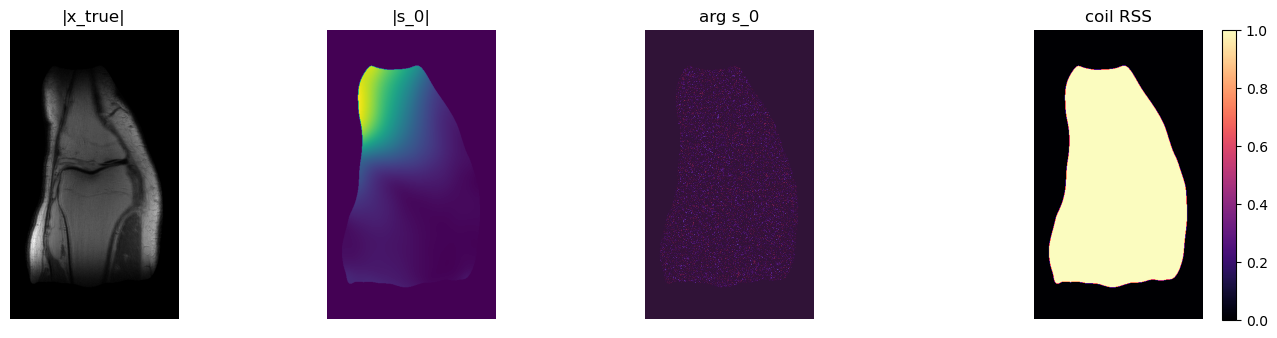

In [3]:
fig, ax = plt.subplots(1, 4, figsize=(14, 3.4))
ax[0].imshow(x_true[0, 0].abs().cpu(), cmap='gray');            ax[0].set_title('|x_true|')
ax[1].imshow(smaps[0, 0].abs().cpu(), cmap='viridis');          ax[1].set_title('|s_0|')
ax[2].imshow(smaps[0, 0].angle().cpu(), cmap='twilight');       ax[2].set_title('arg s_0')
im = ax[3].imshow(rss[0, 0].cpu(), cmap='magma');               ax[3].set_title('coil RSS')
plt.colorbar(im, ax=ax[3], fraction=.046)
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## Testbench helpers

`erode_support` matters more than it looks: `local_noise_std` is a boxcar, so any
window straddling the object edge mixes in the zero background and reads low. Every
"is it flat?" statistic below is taken on the eroded support, or the object boundary
alone would set the coefficient of variation.

In [4]:
def make_gen(seed):
    '''A seeded generator ON THE SAME DEVICE as the data.

    torch.Generator() is CPU-only, and torch.randn(..., device='cuda',
    generator=<cpu gen>) raises

        RuntimeError: Expected a 'cuda' device type for generator but found 'cpu'

    which is the error that bites every time this notebook is run on a GPU. Build
    the generator with device= and it never comes up. Anything drawn on the CPU on
    purpose (see rand_cov) must keep a CPU generator -- the rule is that the
    generator's device has to match the device of the tensor being drawn, not the
    device of the run.
    '''
    return torch.Generator(device=device).manual_seed(int(seed))


def erode_support(keep, ks=9):
    '''Shrink a boolean mask by ks//2 -- min-filter via max-pool on the complement.'''
    import torch.nn.functional as F
    inv = (~keep).to(torch.float32)
    inv = F.max_pool2d(inv, kernel_size=ks, stride=1, padding=ks // 2)
    return inv < 0.5


def cv(t):
    '''Coefficient of variation: the one number that says 'flat' or 'not flat'.'''
    return (t.std() / t.mean().clamp_min(1e-30)).item()


def noise_replicas(recon, smaps, mask, Sigma, nreps, chunk=16, seed=0, keep_first=True):
    '''sqrt(mean_r |recon(xi_r)|^2) over `nreps` noise-only replicas, + one raw draw.'''
    B, C, H, W = smaps.shape
    gen = make_gen(seed)
    acc = torch.zeros(B, 1, H, W, dtype=smaps.real.dtype, device=smaps.device)
    first, done = None, 0
    while done < nreps:
        c = min(chunk, nreps - done)
        xi = sample_kspace_noise((B * c, C, H, W), mask=mask, Sigma=Sigma,
                                 generator=gen, device=smaps.device, dtype=smaps.dtype)
        r = recon(xi)
        if first is None and keep_first:
            first = r[:1].clone()
        acc += r.abs().pow(2).sum(0, keepdim=True)
        done += c
    return (acc / nreps).sqrt(), first


def pe_autocorr(z, keep, axis=-1):
    '''Support-weighted circular autocorrelation along the PE axis, acf[0] = 1.

    Zero-fills outside `keep` and divides by the per-lag overlap count, so the
    object boundary does not fake a decay. Circular is the right convention here:
    the aliasing lattice itself is periodic in PE.
    '''
    a = torch.where(keep, z, torch.zeros_like(z)).movedim(axis, -1)
    m = keep.to(z.dtype).movedim(axis, -1)
    A = torch.fft.fft(a, dim=-1)
    M = torch.fft.fft(m, dim=-1)
    num = torch.fft.ifft(A * A.conj(), dim=-1).sum(dim=(0, 1, 2)).real
    den = torch.fft.ifft(M * M.conj(), dim=-1).sum(dim=(0, 1, 2)).real
    acf = num / den.clamp_min(1.0)
    return (acf / acf[0].clamp_min(1e-30)).cpu()


def build_recon(smaps, mask, accel, acs_size, weighted, Sigma, **cg_kw):
    '''The reconstruction each branch of `sense_noise_level` actually describes.'''
    if not weighted:
        if acs_size:
            raise ValueError("plain pinv + ACS: no matching recon, pass your own")
        return lambda k: block_sense(k, smaps, accel)
    kw = dict(max_iter=400, tol=1e-9); kw.update(cg_kw)
    # lamda = 0 on purpose: any Tikhonov weight changes the noise covariance, and
    # `sense_noise_level` describes the unregularised pinv. The price is that CG
    # wanders in the null space off-support, so all statistics are masked.
    return cg_sense(smaps, mask, lamda=0.0, Sigma=Sigma, **kw)


def show(rows, titles, cmap='magma', vlim=None, figsize=None):
    n = len(rows)
    fig, ax = plt.subplots(1, n, figsize=figsize or (3.4 * n, 3.4))
    ax = np.atleast_1d(ax)
    for a, r, t in zip(ax, rows, titles):
        kw = {} if vlim is None else dict(vmin=vlim[0], vmax=vlim[1])
        im = a.imshow(r.squeeze().cpu(), cmap=cmap, **kw)
        a.set_title(t, fontsize=10); a.axis('off')
        plt.colorbar(im, ax=a, fraction=.046)
    plt.tight_layout(); plt.show()

## 1) One reconstruction, and the residual

Start with the exact regime: uniform undersampling, no ACS, plain pinv --
`block_sense` *is* the estimator `sense_noise_level(..., weighted=False)` describes,
so there is nothing to excuse if this one disagrees.

`Sigma` here is a genuinely correlated coil covariance, not a scaled identity: with
`Sigma = I` the weighted and plain branches coincide and half the code goes
untested.

The mask check is the note's own: the acquired fraction of k-space must equal
$1/A_\text{eff} = 1/A + p - p/A$.

In [5]:
def rand_cov(C, seed=1, strength=0.4, device='cpu'):
    '''Hermitian PD coil covariance, symmetrised explicitly (see the tests).

    Drawn on the CPU in float64 on purpose -- it is a tiny C x C matrix, and keeping
    it off the GPU makes Sigma bit-identical across devices. So this one keeps a
    plain CPU torch.Generator(), NOT make_gen(): the generator's device must match
    the tensor being drawn.
    '''
    g = torch.Generator().manual_seed(seed)
    A = torch.randn(C, C, dtype=torch.complex128, generator=g)
    M = strength * (A @ A.conj().transpose(-2, -1).contiguous()) / C
    M = 0.5 * (M + M.conj().transpose(-2, -1)) + torch.eye(C, dtype=torch.complex128)
    return M.to(DT).to(device)


ACCEL, ACS = 4, 0
assert W % ACCEL == 0, f"accel must divide the PE length ({W})"

# Scale the noise so the pictures look like a reconstruction rather than static.
NOISE = 0.02 * x_true.abs().max().item()
Sigma = (NOISE ** 2) * rand_cov(C, device=device)

mask = make_acc_mask((H, W), ACCEL, acs_lines=ACS, dim=1, device=device)
frac = mask.mean().item()
Aeff = effective_acceleration(ACCEL, ACS, W)
# Exact at acs = 0; with ACS the two differ by O(1/W) because the number of grid
# lines falling inside the band is an integer, not exactly p*W/A.
print(f"acquired fraction {frac:.5f}   1/A_eff = {1 / Aeff:.5f}   A_eff = {Aeff:.4f}"
      f"   (diff {abs(frac - 1 / Aeff):.5f}, tolerance ~1/W = {1 / W:.5f})")

recon = build_recon(smaps, mask, ACCEL, ACS, weighted=False, Sigma=Sigma)
y = mask * fftc(smaps * x_true)
xi = sample_kspace_noise((B, C, H, W), mask=mask, Sigma=Sigma,
                         generator=make_gen(7), device=device, dtype=DT)

x_clean = recon(y)
x_noisy = recon(y + xi)
r_diff = x_noisy - x_clean         # the residual the theory is about
r_direct = recon(xi)               # identical for a linear recon

keep = support_mask(smaps, 2e-2)
lin = (r_diff - r_direct)[keep].abs().max() / r_direct[keep].abs().max()
print(f"\n[linearity]  |r_diff - recon(xi)| / |recon(xi)| = {lin:.3e}   (want ~0)")

bias = (x_clean - x_true)[keep].abs().mean() / x_true[keep].abs().mean()
print(f"[bias]       |x_hat(y) - x_true| / |x_true|      = {bias:.3e}")

# On the phantom the maps used for the recon ARE the maps that generated the data,
# so the bias is ~0 and trap #1 stays invisible. Make it visible: recon with maps
# that are 5% wrong, as any real ESPIRiT estimate is. The ratio below scales like
# (map error)/(noise level), so it gets worse the better your SNR.
MAP_ERR = 0.05
s_err = smaps + MAP_ERR * smaps.abs().max() * torch.randn_like(smaps)
s_err = torch.where(keep, s_err / s_err.abs().pow(2).sum(1, keepdim=True).sqrt(),
                    torch.zeros_like(s_err))
recon_err = build_recon(s_err, mask, ACCEL, ACS, weighted=False, Sigma=Sigma)
r_naive = recon_err(y + xi) - x_true              # the tempting definition
r_ok = recon_err(y + xi) - recon_err(y)           # the right one
sig_err = sense_noise_level(s_err, Sigma, ACCEL, acs_size=ACS, weighted=False)

print(f"\n[trap 1] reconstructing with {MAP_ERR:.0%}-wrong maps")
print(f"   mean |x_hat - x_true|          = {r_naive[keep].abs().mean():.4e}")
print(f"   mean |x_hat(y+xi) - x_hat(y)|  = {r_ok[keep].abs().mean():.4e}")
print("   the decisive difference is whether dividing by sigma flattens it:")
for nm, rr in [('(x_hat - x_true) / sigma', r_naive), ('(noise-only r) / sigma ', r_ok)]:
    zz = torch.where(keep, rr / sig_err.clamp_min(1e-30), torch.zeros_like(rr))
    lz = local_noise_std(zz, ks=9)
    print(f"      CV[local std of {nm}] = {cv(lz[erode_support(keep, 9)]):.4f}"
          f"    E|z|^2 = {zz[keep].abs().pow(2).mean():.3f}")
print("   -> only the noise-only residual flattens to the 0.056 floor at unit power;")
print("      the bias term is structured, so it survives the normalisation.")

acquired fraction 0.25000   1/A_eff = 0.25000   A_eff = 4.0000   (diff 0.00000, tolerance ~1/W = 0.00269)

[linearity]  |r_diff - recon(xi)| / |recon(xi)| = 6.718e-06   (want ~0)
[bias]       |x_hat(y) - x_true| / |x_true|      = 1.071e+00

[trap 1] reconstructing with 5%-wrong maps
   mean |x_hat - x_true|          = 4.0477e-01
   mean |x_hat(y+xi) - x_hat(y)|  = 1.2230e-01
   the decisive difference is whether dividing by sigma flattens it:
      CV[local std of (x_hat - x_true) / sigma] = 0.3519    E|z|^2 = 17.372
      CV[local std of (noise-only r) / sigma ] = 0.0549    E|z|^2 = 1.001
   -> only the noise-only residual flattens to the 0.056 floor at unit power;
      the bias term is structured, so it survives the normalisation.


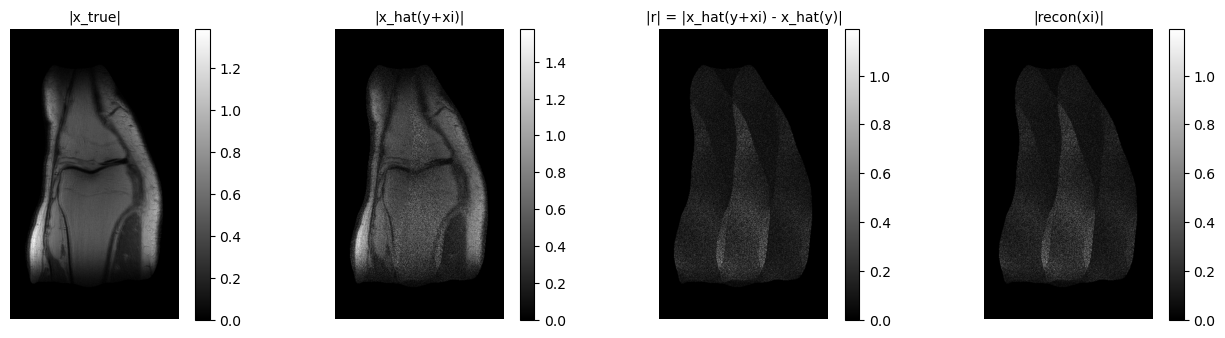

In [6]:
show([x_true[0, 0].abs(), x_noisy[0, 0].abs(), r_diff[0, 0].abs(), r_direct[0, 0].abs()],
     ['|x_true|', '|x_hat(y+xi)|', '|r| = |x_hat(y+xi) - x_hat(y)|', '|recon(xi)|'],
     cmap='gray')

## 2) The raw residual is spatially structured

Compare a local (boxcar) standard deviation of the residual against the analytic
map. They should agree in shape *and* scale -- the local std is a real estimate of
$\sigma$, just a noisy one (a $9\times9$ window is 81 samples, so ~8% per pixel).

The g-factor panel shows where the structure comes from: it is the conditioning of
the per-pixel $A\times A$ unfolding, worst where the aliased coil vectors are most
nearly parallel.

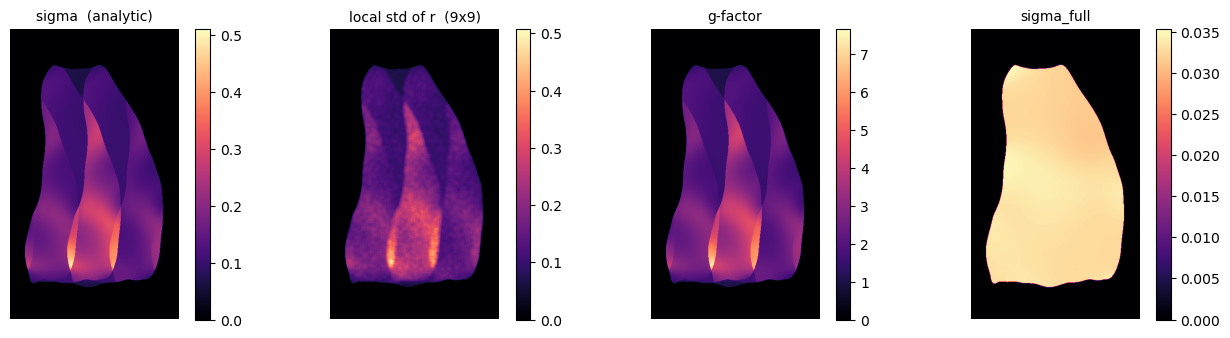

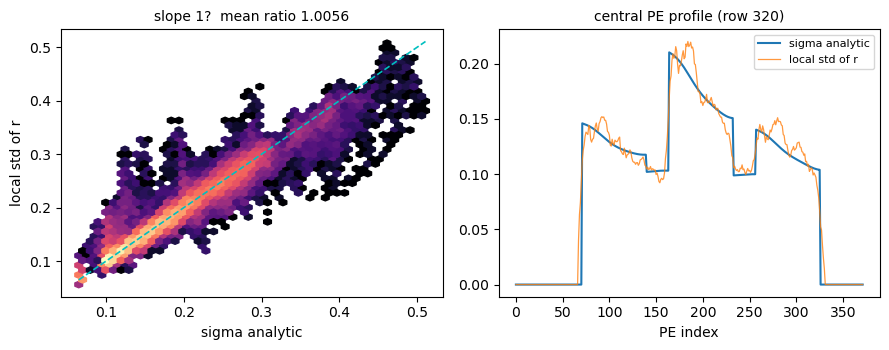

local std of r  : CV = 0.3740   <- spatially varying


In [7]:
sigma = sense_noise_level(smaps, Sigma, ACCEL, acs_size=ACS, weighted=False)
gmap = sense_gfactor(smaps, Sigma, ACCEL, acs_size=ACS, weighted=False)
sig_full = coil_combined_noise_level(smaps, Sigma, weighted=False)

keep_e = erode_support(keep, ks=9)          # boxcar-safe interior
ls_r = local_noise_std(r_diff, ks=9)

show([sigma[0, 0] * keep[0, 0], ls_r[0, 0] * keep[0, 0],
      gmap[0, 0] * keep[0, 0], sig_full[0, 0] * keep[0, 0]],
     ['sigma  (analytic)', 'local std of r  (9x9)', 'g-factor', 'sigma_full'])

sl = ls_r[keep_e]; sa = sigma[keep_e]
fig, ax = plt.subplots(1, 2, figsize=(9, 3.6))
ax[0].hexbin(sa.cpu(), sl.cpu(), gridsize=45, bins='log', cmap='magma')
lo, hi = sa.min().item(), sa.max().item()
ax[0].plot([lo, hi], [lo, hi], 'c--', lw=1.2)
ax[0].set_xlabel('sigma analytic'); ax[0].set_ylabel('local std of r')
ax[0].set_title(f'slope 1?  mean ratio {(sl / sa).mean():.4f}', fontsize=10)

ax[1].plot(sigma[0, 0, H // 2].cpu(), label='sigma analytic')
ax[1].plot(ls_r[0, 0, H // 2].cpu(), lw=.9, alpha=.8, label='local std of r')
ax[1].set_title(f'central PE profile (row {H // 2})', fontsize=10)
ax[1].set_xlabel('PE index'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"local std of r  : CV = {cv(sl):.4f}   <- spatially varying")

## 3) Divide by the map

$z = r/\sigma$. If the map is right, `local_noise_std(z)` is flat at 1 and the CV
collapses. Two controls make the result non-vacuous:

* **global constant** -- dividing by a single scalar. If the CV dropped this much
  anyway, the map would be doing nothing.
* **g-factor** -- what you would divide by if you conflated the two. Off by the
  constant $\sqrt{A_\text{eff}}$ *and* by the $\sigma_\text{full}$ shape; with the
  phantom's exactly-unit-RSS maps only the constant survives, with real ESPIRiT maps
  both do.

A floor on the CV is expected and is not error in the map. A standard deviation
estimated from $K$ complex samples has relative spread $1/(2\sqrt{K})$, so a
$9\times9$ boxcar bottoms out at $1/18 \approx 5.6\%$ however perfect the map is.
The target is not CV $\to 0$; it is CV $\to$ that floor.

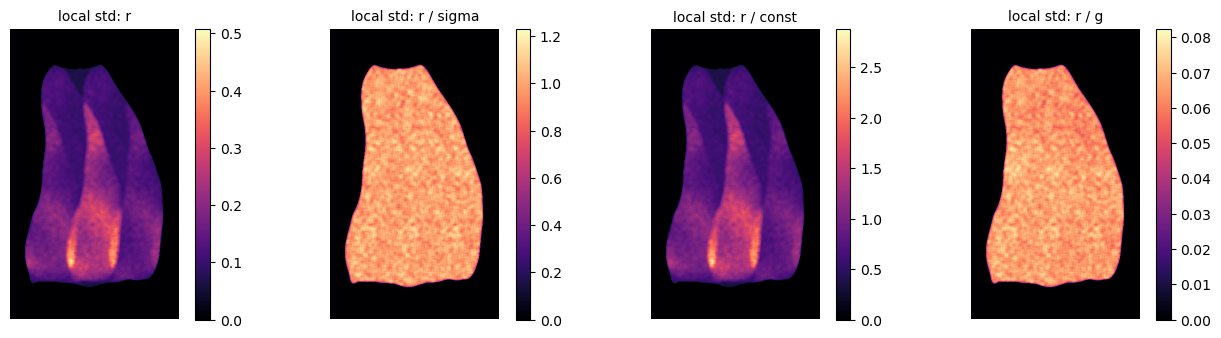

CV of the local-std map   (lower = flatter; estimator floor ~0.056)
   r  (unnormalised)    0.3740
   r / sigma            0.0551
   r / global const     0.3740
   r / g-factor         0.0596

E|z|^2  = 1.0027   (want 1.000)
var Re z = 0.4983, var Im z = 0.5044   (want 0.500 each: a complex randn splits unit power evenly)


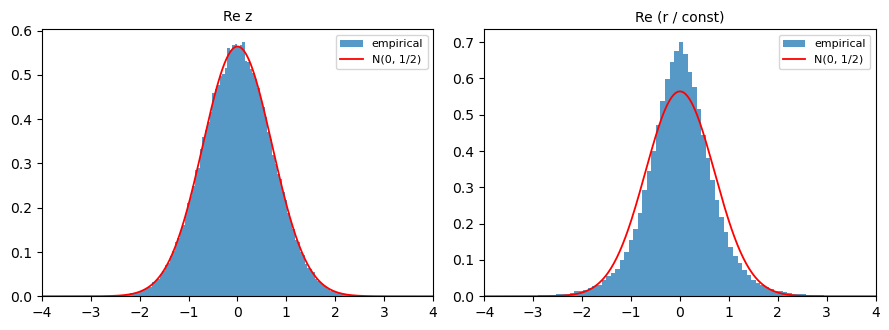

In [8]:
z = torch.where(keep, r_diff / sigma.clamp_min(1e-30), torch.zeros_like(r_diff))
z_const = r_diff / r_diff[keep].abs().pow(2).mean().sqrt()
z_g = torch.where(keep, r_diff / gmap.clamp_min(1e-30), torch.zeros_like(r_diff))

ls_z = local_noise_std(z, ks=9)
ls_c = local_noise_std(z_const, ks=9)
ls_g = local_noise_std(z_g, ks=9)

show([ls_r[0, 0] * keep[0, 0], ls_z[0, 0] * keep[0, 0],
      ls_c[0, 0] * keep[0, 0], ls_g[0, 0] * keep[0, 0]],
     ['local std: r', 'local std: r / sigma', 'local std: r / const',
      'local std: r / g'])

KS = 9
floor = 1 / (2 * KS)      # rel. std of a std estimated from KS^2 complex samples
print(f"CV of the local-std map   (lower = flatter; estimator floor ~{floor:.3f})")
for nm, t in [('r  (unnormalised)', ls_r), ('r / sigma', ls_z),
              ('r / global const ', ls_c), ('r / g-factor', ls_g)]:
    print(f"   {nm:<20s} {cv(t[keep_e]):.4f}")

zk = z[keep]
print(f"\nE|z|^2  = {zk.abs().pow(2).mean():.4f}   (want 1.000)")
print(f"var Re z = {zk.real.var():.4f}, var Im z = {zk.imag.var():.4f}   (want 0.500 each:"
      " a complex randn splits unit power evenly)")

fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
for a, (dat, ttl) in zip(ax, [(zk.real, 'Re z'), (z_const[keep].real, 'Re (r / const)')]):
    a.hist(dat.cpu().numpy(), bins=120, density=True, alpha=.75, label='empirical')
    t = np.linspace(-4, 4, 400)
    a.plot(t, np.exp(-t ** 2) / np.sqrt(np.pi), 'r-', lw=1.3, label='N(0, 1/2)')
    a.set_title(ttl, fontsize=10); a.legend(fontsize=8); a.set_xlim(-4, 4)
plt.tight_layout(); plt.show()

## 4) Pixel-wise verification against replicas

Section 3 is a single realization: it can only show that the *shape* is right, since
one sample per pixel says nothing pixel-wise. The pixel-wise statement needs
replicas -- push many noise draws through the same reconstruction and compare
$\sigma_\text{emp}$ to $\sigma$ at every pixel.

This gives a sharp quantitative target rather than a loose bound. $|r|^2/\sigma^2$
is exponential (unit mean, unit variance), so averaging $R$ replicas gives
$\sigma^2_\text{emp}$ a relative spread of $1/\sqrt{R}$ and hence
$\sigma_\text{emp}$ a spread of exactly

$$ \operatorname{std}(\sigma_\text{emp}/\sigma) = \frac{1}{2\sqrt{R}} . $$

So the ratio map's std should *equal* that number, not merely stay under it. Coming
in above means model error on top of replica noise; the mean should sit at 1.000.
A ratio map with visible spatial structure means the model is wrong; one that looks
like unstructured salt-and-pepper at exactly $1/(2\sqrt{R})$ means it is right and
you are looking at nothing but replica noise.

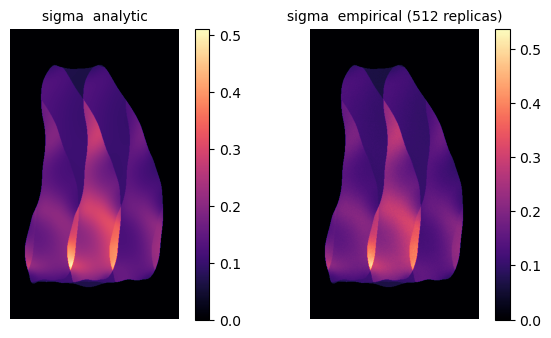

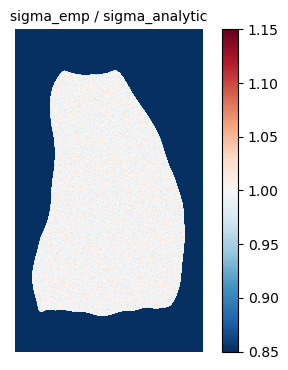

ratio  mean 0.9998   std 0.0220   (replica floor 0.0221)
       p1 0.9495   p50 0.9998   p99 1.0515
       max |ratio - 1| = 0.0943


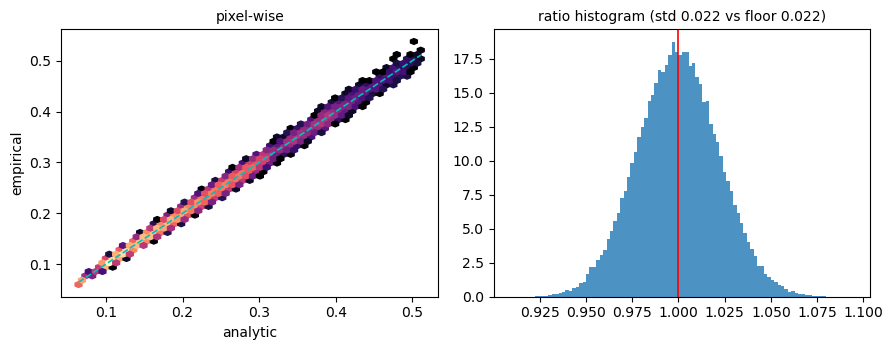

In [9]:
NREPS = 512
sig_emp, _ = noise_replicas(recon, smaps, mask, Sigma, NREPS, chunk=32, seed=1)
ratio = torch.where(keep, sig_emp / sigma.clamp_min(1e-30), torch.zeros_like(sigma))
rk = ratio[keep]

show([sigma[0, 0] * keep[0, 0], sig_emp[0, 0] * keep[0, 0]],
     ['sigma  analytic', f'sigma  empirical ({NREPS} replicas)'])
show([ratio[0, 0] * keep[0, 0]], ['sigma_emp / sigma_analytic'],
     cmap='RdBu_r', vlim=(0.85, 1.15), figsize=(4.6, 3.8))

floor = 1 / (2 * NREPS ** 0.5)
print(f"ratio  mean {rk.mean():.4f}   std {rk.std():.4f}   "
      f"(replica floor {floor:.4f})")
print(f"       p1 {rk.quantile(.01):.4f}   p50 {rk.median():.4f}   p99 {rk.quantile(.99):.4f}")
print(f"       max |ratio - 1| = {(rk - 1).abs().max():.4f}")

fig, ax = plt.subplots(1, 2, figsize=(9, 3.6))
ax[0].hexbin(sigma[keep].cpu(), sig_emp[keep].cpu(), gridsize=50, bins='log', cmap='magma')
lo, hi = sigma[keep].min().item(), sigma[keep].max().item()
ax[0].plot([lo, hi], [lo, hi], 'c--', lw=1.2)
ax[0].set_xlabel('analytic'); ax[0].set_ylabel('empirical'); ax[0].set_title('pixel-wise', fontsize=10)
ax[1].hist(rk.cpu().numpy(), bins=100, density=True, alpha=.8)
ax[1].axvline(1.0, color='r', lw=1.2)
ax[1].set_title(f'ratio histogram (std {rk.std():.3f} vs floor {floor:.3f})', fontsize=10)
plt.tight_layout(); plt.show()

## 5) What "white" does and does not mean

The per-pixel variance is now flat, so the residual is white in the sense that
matters for a noise-adaptive denoiser: one scalar $\sigma_t$ times a known shape.
It is *not* spatially white. Without ACS the covariance sits exactly on the aliasing
lattice, so the autocorrelation of $z$ along PE is

* a spike at lag 0, and
* $A-1$ spikes at lags $\pm j\,W/A$,

and nothing anywhere else. That is a sharp, falsifiable prediction -- the marked
lags below should be the *only* nonzero ones.

Adding ACS changes the regime: the sinc terms in $M_\Omega^\text{conv}$ introduce
*local* correlations on a $\sim 1/p$ pixel scale and the matrix inverse spreads them
further, so the ACF grows a narrow local lobe on top of the lattice spikes. Both
panels are plotted; the ACS one is why the note says diagonal-only approximations
are fine for Rep2Rep-style losses and not for SURE.

acs= 0: |acf| at lattice lags 93:0.554, 186:0.026, 279:0.554   max elsewhere 0.001   near-lag (1-3) 0.000
acs=16: |acf| at lattice lags 93:0.598, 186:0.019, 279:0.598   max elsewhere 0.053   near-lag (1-3) 0.062


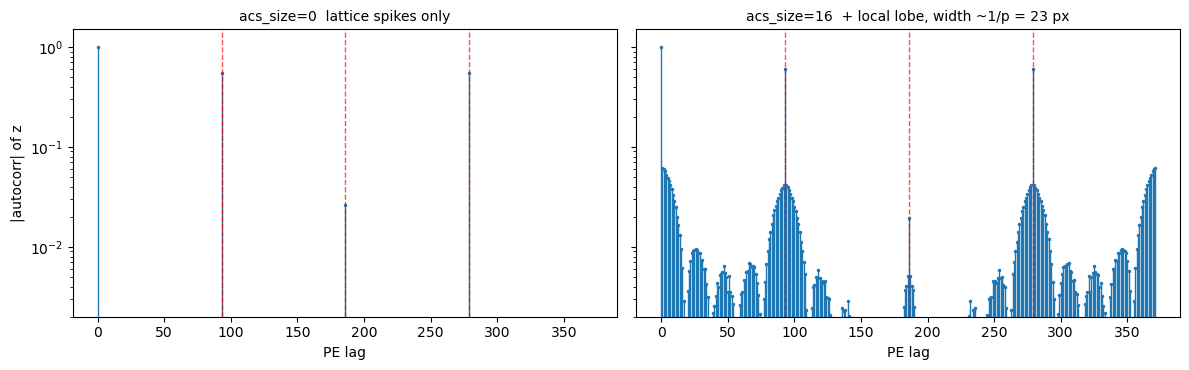

In [10]:
def replica_acf(accel, acs, weighted, nreps=64, chunk=16, seed=3):
    '''ACF of z averaged over replicas -- one draw is far too noisy to read.'''
    m = make_acc_mask((H, W), accel, acs_lines=acs, dim=1, device=device)
    rc = build_recon(smaps, m, accel, acs, weighted, Sigma)
    sg = sense_noise_level(smaps, Sigma, accel, acs_size=acs, weighted=weighted)
    kp = support_mask(smaps, 2e-2) & (sg > 0)
    gen = make_gen(seed)
    num = None
    done = 0
    while done < nreps:
        c = min(chunk, nreps - done)
        xi = sample_kspace_noise((B * c, C, H, W), mask=m, Sigma=Sigma, generator=gen,
                                 device=device, dtype=DT)
        zz = torch.where(kp, rc(xi) / sg.clamp_min(1e-30), torch.zeros_like(sg, dtype=DT))
        a = pe_autocorr(zz, kp.expand_as(zz)) * c
        num = a if num is None else num + a
        done += c
    return (num / done).abs().numpy()


fig, ax = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
lags = np.arange(W)
lattice = [j * W // ACCEL for j in range(1, ACCEL)]

for a, (acs, w) in zip(ax, [(0, False), (max(ACS, 16), True)]):
    acf = replica_acf(ACCEL, acs, w)
    a.vlines(lags, 1e-6, np.maximum(acf, 1e-6), color='C0', lw=1)
    a.plot(lags, np.maximum(acf, 1e-6), '.', ms=3, color='C0')
    for j in lattice:
        a.axvline(j, color='r', ls='--', lw=1, alpha=.7)
    a.set_yscale('log'); a.set_ylim(2e-3, 1.5); a.set_xlabel('PE lag')
    a.set_title(f"acs_size={acs}  " + ('lattice spikes only' if acs == 0 else
                f'+ local lobe, width ~1/p = {W / acs:.0f} px'), fontsize=10)

    peaks = {j: float(acf[j]) for j in lattice}
    other = [v for i, v in enumerate(acf)
             if i and all(abs(i - j) > 2 for j in lattice) and min(i, W - i) > 3]
    print(f"acs={acs:>2}: |acf| at lattice lags " +
          ", ".join(f"{j}:{v:.3f}" for j, v in peaks.items()) +
          f"   max elsewhere {max(other):.3f}"
          f"   near-lag (1-3) {max(acf[1:4]):.3f}")
ax[0].set_ylabel('|autocorr| of z'); plt.tight_layout(); plt.show()

## 6) Sweep: all three regimes, several accelerations

The summary table. `ratio` is $\text{mean}(\sigma_\text{emp}/\sigma)$ over the
support -- 1.000 is a pass for the exact regimes, and the ACS rows are *expected* to
sit above 1 because the closed form replaces the ACS sinc by a delta and then
inverts it, which over-states the information the ACS supplies.

`CV before / after` is the flatness collapse from Section 3, which is the thing the
consumer of these maps actually cares about. Read it against the $1/(2\cdot 9)
= 0.056$ boxcar floor, and note that at $A = 2$ there is barely anything to
flatten -- this phantom's g-factor is nearly 1 everywhere, so `CV before` already
sits near the floor and the test has no teeth. $A = 4$ is where it does.

Watch the ACS rows' `ratio` as $A$ grows. The optimism is not a fixed few percent:
it compounds with the conditioning of the uniform part, because the bracket credits
the ACS with full-resolution information at weight $p$ and that fiction matters more
the more the uniform term needs the help. `r.std` climbing away from the floor on
those rows says the *shape* is off too, not just the scale -- so at high
acceleration with ACS these maps should be treated as a lower bound on the noise,
not an estimate of it.

In [11]:
def bench(accel, acs, weighted, nreps=256, chunk=32, seed=0):
    m = make_acc_mask((H, W), accel, acs_lines=acs, dim=1, device=device)
    rc = build_recon(smaps, m, accel, acs, weighted, Sigma)
    sg = sense_noise_level(smaps, Sigma, accel, acs_size=acs, weighted=weighted)
    kp = support_mask(smaps, 2e-2) & (sg > 0)
    kpe = erode_support(kp, 9)
    se, r1 = noise_replicas(rc, smaps, m, Sigma, nreps, chunk=chunk, seed=seed)
    zz = torch.where(kp, r1 / sg.clamp_min(1e-30), torch.zeros_like(r1))
    rt = (se / sg.clamp_min(1e-30))[kp]
    g = sense_gfactor(smaps, Sigma, accel, acs_size=acs, weighted=weighted)
    return dict(ratio=rt.mean().item(), rstd=rt.std().item(),
                cv_before=cv(local_noise_std(r1, 9)[kpe]),
                cv_after=cv(local_noise_std(zz, 9)[kpe]),
                power=zz[kp].abs().pow(2).mean().item(),
                gmed=g[kp].median().item(), gmax=g[kp].max().item(),
                floor=1 / (2 * nreps ** 0.5))


CANDIDATES = (2, 3, 4)
accels = [a for a in CANDIDATES if W % a == 0]
skipped = [a for a in CANDIDATES if W % a]
if skipped:
    print(f"skipping accel {skipped}: the alias-set block structure needs accel | W={W}\n")

rows = []
for accel in accels:
    rows.append(('plain / no ACS ', accel, 0, False, bench(accel, 0, False)))
    rows.append(('weighted / no ACS', accel, 0, True, bench(accel, 0, True)))
    rows.append(('weighted / ACS   ', accel, 16, True, bench(accel, 16, True)))

hdr = (f"{'regime':<18}{'A':>2} {'acs':>4} | {'ratio':>7} {'r.std':>7} {'floor':>6} |"
       f" {'CV before':>9} {'CV after':>9} | {'E|z|^2':>7} | {'g med':>6} {'g max':>6}  status")
print(hdr); print('-' * len(hdr))
for name, accel, acs, w, d in rows:
    exact = (acs == 0)
    ok = abs(d['ratio'] - 1) < max(3 * d['floor'], 0.02) if exact else d['ratio'] > 1
    tag = ('exact, ' + ('PASS' if ok else 'FAIL')) if exact else \
          ('approx, optimistic by %.0f%%' % (100 * (d['ratio'] - 1)))
    print(f"{name:<18}{accel:>2} {acs:>4} | {d['ratio']:>7.4f} {d['rstd']:>7.4f} "
          f"{d['floor']:>6.4f} | {d['cv_before']:>9.4f} {d['cv_after']:>9.4f} | "
          f"{d['power']:>7.4f} | {d['gmed']:>6.3f} {d['gmax']:>6.3f}  {tag}")

_LinAlgError: cusolver error: CUSOLVER_STATUS_INVALID_VALUE, when calling `cusolverDnCheevjBatched_bufferSize( handle, jobz, uplo, n, reinterpret_cast<const cuComplex*>(A), lda, W, lwork, params, batchsize)`. This error may appear if the input matrix contains NaN. If you keep seeing this error, you may use `torch.backends.cuda.preferred_linalg_library()` to try linear algebra operators with other supported backends. See https://pytorch.org/docs/stable/backends.html#torch.backends.cuda.preferred_linalg_library

## 7) Notes for using this on real data

* **Correlated coil noise.** Everything above injects a known `Sigma`, which is the
  only way to *verify* anything. On real data you either estimate it
  (`physics.nle.ncov_est`) and pass it in, or whiten up front
  (`physics.nle.whiten_from_kspace`) and use `Sigma=None` -- after whitening the
  weighted and plain branches coincide, so the choice stops mattering.

* **Regularization changes the answer.** `sense_noise_level` describes the
  unregularised pinv. Any Tikhonov `lamda` shrinks the noise (and biases the
  estimate); `physics.gfactor.gfactor_uniform` has a `lamda` knob for `nvar` that
  covers that case at `acs_size = 0`. Do not compare a `lamda > 0` recon against
  these maps and expect ratio 1.

* **Nonlinear reconstructions.** For a regularized or learned recon, keep the
  difference form $\hat{x}(y+\xi)-\hat{x}(y)$ with a *small* $\xi$ -- you are then
  measuring the local Jacobian, which is the only thing a linear noise model can
  describe. `physics.gfactor.gfactor_replica` takes a `y` argument for exactly this.

* **Off the uniform grid.** Random or variable-density masks break the alias-set
  block structure that the whole closed form rests on; there is no `sense_noise_level`
  for them. Use `gfactor_replica` with your actual reconstruction.

* **Consuming the maps.** `physics.gfactor.normalize_gmap(sigma**2, mask)` puts the
  variance in the mean-1 form ImMAP's `sigma_t` update expects, so
  `sigma_t^2 <- ||(z_hat - z)/sqrt(g)||^2/N` keeps its usual meaning.

## 8) One ImMAP-1 run, with and without the g-factor

`whiten -> g-factor -> immap1`, following the pattern in `notebooks/immap.ipynb`.
Two inference runs on one slice, so this cell is affordable.

**This is a measurement experiment, not a simulation.** Nothing here synthesises
noise. The input is `mask * kspace_w` -- the real acquired k-space, retrospectively
undersampled and whitened -- and the noise level `sigma_y` comes from the data via
`whiten`'s covariance estimate, not from a number we chose. Sections 1-6 above are
the opposite by necessity: to *verify* a noise model you have to know the answer, so
they inject a known `Sigma`. This section spends that credibility rather than
rebuilding it, and the one thing it does check is the link between the two: that
whitening actually delivered white noise, because if it did not then `sigma_y` is
wrong and so is everything downstream.

Whitening earns its place three times over: `physics.nle.whiten` returns `smaps_w`
renormalised to **unit RSS**, which is the precondition `sense_noise_level` needs;
it leaves the coil noise white, so `Sigma = None` is exact and the weighted and
plain pinv branches coincide; and it hands back `sigma_n`, the k-space noise std in
the rescaled units, which is exactly the scalar `noise_level` ImMAP-1 wants. Working
from un-whitened data you would have to estimate a full `Sigma` for the g-factor
*and* hand ImMAP-1 a scalar it cannot represent.

`g` is `normalize_gmap(sigma**2, support)`: the **mean-1 variance** map, strictly
positive (1 off-support). All three places ImMAP-1 touches `g` assume that form --
see the notes in the cell.

`accel` no longer has to divide the PE length. Passing `mask=` reads the sampling
kernel off the actual pattern, so the house `accel=6` on a 368-wide knee works --
`arange(off, 368, 6)` keeps 62 lines, not 61.33, and only `gcd(6, 368) = 2` of the
six folds sit on an exact lattice; the other four smear over two pixels each, so the
alias block is built from the bracketing integers (10 lags, not 6).

Be aware of what that costs. Measured against CG-SENSE replicas at `acs_size = 0`:

| | level err | shape err |
|---|---|---|
| A=4, N=48 (divisible) | 2.8% | 5.5% |
| A=3, N=46 | 4.1% | 5.1% |
| A=6, N=46 | 18.2% | 9.5% |
| A=6, N=184 | 24.5% | 11.1% |

The divisible row and A=3 sit at the replica floor, so the machinery is right. At
A=6 the *level* is under-predicted by ~20%, and that does **not** improve on a
bigger image -- the Dirichlet peak is ~1 pixel wide whatever N is, so a half-pixel
offset always lands mid-peak. But the error is mostly a global scale bias, and
`normalize_gmap` divides scale out: the mean-1 **shape**, which is all ImMAP sees,
is good to ~10%. That is why this is usable here and would not be if you wanted an
absolute noise level -- for that use `physics.gfactor.gfactor_replica`.

One consequence worth knowing: because ImMAP only consumes the mean-1 *shape*, the
ACS branch's overall scale bias (51% at A=4 in Section 6) divides straight out. What
survives is only its per-pixel shape error, ~15% there. So including the ACS lines
is the right call even though the closed form is approximate.

What to look for is *not* mainly NRMSE. The claim behind passing `g` is that error
should stop concentrating where the unfolding is ill-conditioned, so the panels show
`|err|` and `|err|/sqrt(g)`: if `g` is doing its job the second is flatter for the
g-aware run. `corr(|err|^2, g)` and the high-g/low-g error ratio put numbers on it.

In [14]:
import math

from diffusion.common import init_diff
from operators import FFT2D, Identity, Mask, Sense
from physics.gfactor import local_noise_std, normalize_gmap
from physics.nle import ncov_est_undersampled, whiten_from_kspace
from physics.sense_noise import sense_noise_level
from solvers.cg import cg
from training.common import load_model
from visualization.image import plot_image

# ---- knobs ---------------------------------------------------------------
FNAME       = 'file1000052.h5'
SLICE       = 15
ACCEL       = 6        # any value now: the g-factor reads the kernel off the mask
ACS_LINES   = 20
SIGMA_MIN   = 0.05     # 0.01 for a full run; 0.05 roughly halves the iterations
DENOISER    = '/home/ee2178/scratch/ee2178/ImMAP/trained_nets/knee/LPDS_Denoiser/config.json'

# ---- 1) data + mask ------------------------------------------------------
kspace, smaps_raw, knee_mask, gnd_truth = load_knee_data(
    kspace_fname=FNAME, slice_idx=SLICE, device=device)
Wpe = kspace.shape[-1]
mask = make_acc_mask(shape=kspace[0, 0].shape, accel=ACCEL,
                     acs_lines=ACS_LINES, device=device)
print(f"PE={Wpe}  accel={ACCEL}  acs={ACS_LINES}  "
      f"lines kept {int((mask != 0).any(-2).sum())}  "
      f"A_eff={effective_acceleration(mask=mask):.3f}"
      + ("" if Wpe % ACCEL == 0 else
         f"   [accel does not divide {Wpe}: exact lattice order "
         f"{math.gcd(ACCEL, Wpe)}/{ACCEL}, rest is nearest-integer]"))

# ---- 2) whiten -----------------------------------------------------------
# Returns smaps_w already renormalised to unit RSS, and Zinv to undo the
# whitening rescale for display. sigma_n is the k-space noise std in the
# rescaled whitened units, i.e. exactly ImMAP-1's scalar `noise_level`.
kspace_w, image_w, smaps_w, sigma_n, _, Zinv = whiten_from_kspace(
    kspace, smaps_raw, mask=mask, R=ACCEL, gnd_truth_kspace=kspace)
meas_kspace = mask * kspace_w          # THE MEASURED DATA. no synthetic noise.
E = Mask(mask) @ FFT2D() @ Sense(smaps_w)
sigma_y = sigma_n

# Did whitening actually whiten? Re-estimate the coil covariance on the whitened
# multicoil image; it should be sigma_y^2 * I. If the off-diagonals survive, or the
# diagonal is not flat, sigma_y is not the noise level and nothing below is safe.
Sig_w = ncov_est_undersampled(ifftc(meas_kspace), ACCEL, mask)[0] / sigma_y ** 2
d = Sig_w.diagonal().real
offd = (Sig_w - torch.diag(Sig_w.diagonal())).abs()
print(f"sigma_y = {float(sigma_y):.4g}   (from the data, not chosen)")
print(f"whitened coil cov / sigma_y^2:  diag mean {d.mean():.3f} (want 1)  "
      f"spread {d.std() / d.mean():.3f}")
print(f"  worst |off-diagonal| {offd.max():.3f}, mean {offd.mean():.3f} (want ~0)")
if d.std() / d.mean() > 0.25 or offd.max() > 0.25:
    print("  WARNING: whitening left structure behind, so sigma_y is unreliable.")
    print("  Check the ACS extent feeding ncov_est_undersampled before trusting")
    print("  either the g-factor or ImMAP-1's data-consistency weight.")

# ---- 3) g-factor ---------------------------------------------------------
sup = support_mask(smaps_w, 2e-2)
# mask= is the point: exact kernel taps, and no accel | PE requirement.
sigma_map = sense_noise_level(smaps_w, None, ACCEL, mask=mask, weighted=True)
G = normalize_gmap(sigma_map.pow(2), mask=sup)
assert (G > 0).all(), "g must be strictly positive; normalize_gmap gives 1 off-support"
dyn = (G[sup].quantile(.99) / G[sup].quantile(.01)).item()
print(f"g: mean-on-support {G[sup].mean():.4f} (want 1)  p1 {G[sup].quantile(.01):.3f}  "
      f"p99 {G[sup].quantile(.99):.3f}  dynamic range {dyn:.2f}x")
if dyn < 1.5:
    print(f"  NOTE: g is nearly flat ({dyn:.2f}x), so the two runs cannot differ much.")
    print(f"  {ACS_LINES} ACS lines make the unfolding well conditioned, which is")
    print("  exactly what flattens g. Drop ACS_LINES or raise ACCEL to give g work.")

net = load_model(DENOISER, device=device)

Loading slice 15 from /home/ee2178/scratch/ee2178/datasets/fastmri/knee/multicoil_val/file1000052.h5
PE=372  accel=6  acs=20  lines kept 79  A_eff=4.709
sigma_y = 0.01763   (from the data, not chosen)
whitened coil cov / sigma_y^2:  diag mean 0.998 (want 1)  spread 0.001
  worst |off-diagonal| 0.001, mean 0.000 (want ~0)
g: mean-on-support 1.0000 (want 1)  p1 0.499  p99 1.266  dynamic range 2.54x
Power method returns L = (3425.94384765625-7.413327693939209e-07j)


In [39]:
def immap1_g(y, noise_level, denoiser, E, g=None,
             sigma_max=1.0, sigma_min=0.01, beta=0.05, h_0=0.01,
             save_dir=None, verbose=False, max_steps=2000):
    '''ImMAP-1 with an optional mean-1 variance map `g`. g=None reproduces vanilla.

    Three lines differ from the vanilla loop, and each one is a place the pasted
    draft had it wrong:
      * sigma_t^2 = mean(|xhat - x|^2 / g)   -- divide the SQUARED residual by g.
        Dividing the amplitude by g instead treats g as an amplitude, which
        contradicts the sqrt(g) below and inflates sigma_t by sqrt(E[1/g^2]).
      * Sigma_t = sigma_y^2 I + E R_t E^H with R_t = sigma_t^2 g/(1+sigma_t^2 g).
        R_t must sit BETWEEN E and E^H: `R_t * E(E.H(x))` applies an image-domain
        map in k-space, is ~33% non-Hermitian (so CG is solving a system that is
        not the covariance) and rotates the gradient by ~56% per step.
      * noise injection scaled by sqrt(g), matching g being a variance.
    Expect sigma_1 to come in high by ~sqrt(E[1/g]) even when correct: x_t starts
    isotropic, so the g-weighted estimate is only self-consistent once the state
    actually carries the g shape.
    '''
    # NB: init_diff returns FOUR values. diffusion/immap.py::immap1 unpacks five,
    # so that function raises ValueError as committed -- fix it there too.
    x_t, t, sigma_t, sigma_t_prev = init_diff(y, sigma_max=sigma_max)
    EHy = E.H(y)
    x_t = x_t + EHy
    if g is None:
        g = torch.ones_like(EHy.real)          # real, not complex
    trace = []

    with torch.no_grad():
        while sigma_t > sigma_min and len(trace) < max_steps:
            def denoise(x, sigma, f=denoiser):
                x_hat, _ = f(x, Identity(), sigma=sigma)
                return x_hat
            x_hat_t = denoise(x_t, sigma_t)

            sigma_t_sq = torch.mean((x_hat_t - x_t).abs() ** 2 / g)
            sigma_t = sigma_t_sq ** 0.5
            grad_prior = (x_hat_t - x_t)                      # Tweedie, x sigma_t^2

            r_t = sigma_t_sq * g / (1 + sigma_t_sq * g)

            def S_t(x, E=E, r_t=r_t, noise_level=noise_level):
                return noise_level ** 2 * x + E(r_t * E.H(x))

            v_t, tol_reached = cg(S_t, E(x_hat_t) - y, max_iter=500, tol=1e-3)
            _, (grad_likelihood, _) = torch.autograd.functional.vjp(
                denoise, (x_t, sigma_t), E.H(v_t))
            grad_likelihood = -1 * sigma_t_sq * grad_likelihood

            h_t = h_0 * t / (1 + h_0 * (t - 1))
            gamma_t = sigma_t_sq ** 0.5 * ((1 - beta * h_t) ** 2 - (1 - h_t) ** 2) ** 0.5
            x_t = x_t + h_t * (grad_prior + grad_likelihood) \
                      + g.sqrt() * gamma_t * torch.randn_like(x_t)

            trace.append(float(sigma_t))
            t += 1
            if verbose:
                print(f"  it {t:3d}  sigma_t {float(sigma_t):.4f}  cg_tol {tol_reached}")
    return x_t, trace


import time
runs = {}
for name, gg in [('without g', None), ('with g', G)]:
    torch.manual_seed(0)                       # same init + same noise draws
    t0 = time.time()
    xh, tr = immap1_g(meas_kspace, sigma_y, net, E, g=gg, sigma_min=SIGMA_MIN)
    runs[name] = dict(x=xh * Zinv, trace=tr, secs=time.time() - t0)
    print(f"{name:<10}: {len(tr)} iterations, {runs[name]['secs']:.0f}s, "
          f"sigma_1 {tr[0]:.4f} -> sigma_end {tr[-1]:.4f}")

without g : 109 iterations, 70s, sigma_1 0.9965 -> sigma_end 0.0480
with g    : 109 iterations, 72s, sigma_1 1.0044 -> sigma_end 0.0479


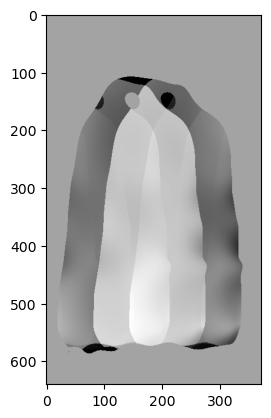

In [43]:
plt.imshow(G.detach().cpu().squeeze(), cmap = 'gray')

reference is complex; comparing complex images
run           NRMSE    PSNR  corr(e2,g)  err hi-g/lo-g   CV |e|  CV |e|/sqrt(g)
-------------------------------------------------------------------------------
without g    0.2138   28.54       0.039           5.79    1.046           1.013
with g       0.2190   28.34       0.043           6.49    1.053           1.020

corr and hi-g/lo-g should move toward 0 and 1 if g is helping; CV |e|/sqrt(g)
below CV |e| means the error really does carry the g shape.


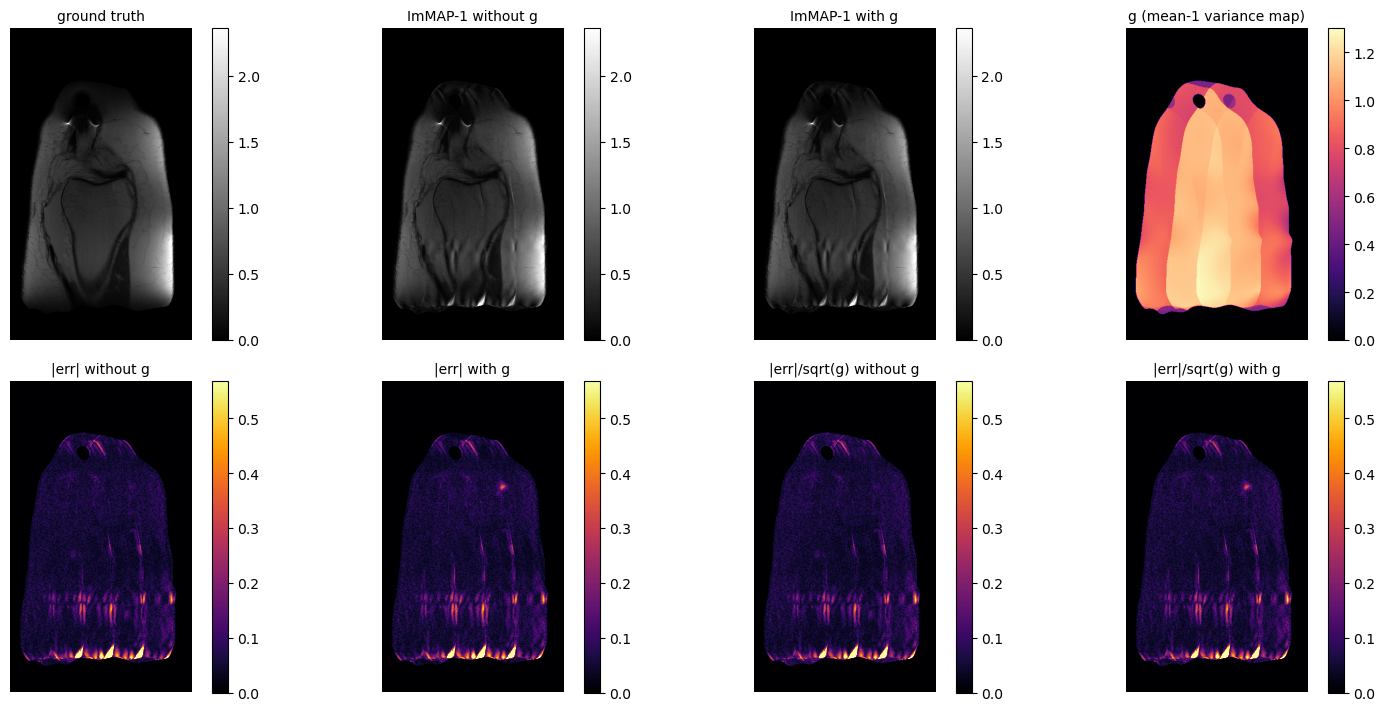

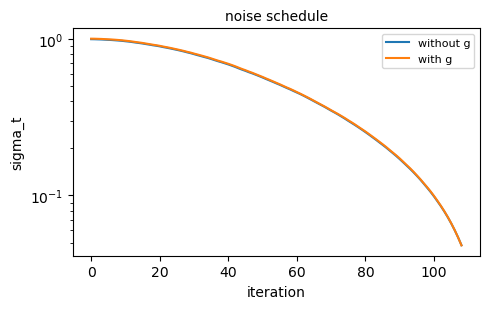

In [40]:
# `gnd_truth` is whatever was stored in the smaps file's 'image' key, which may be
# magnitude-only. Compare magnitudes in that case, else complex.
ref = gnd_truth[None]
CMPLX = ref.is_complex()


def align(xh, xt, m):
    '''ImMAP is free up to a global scale (and phase, if the reference is complex).'''
    H, W = xh.shape[-2:]
    xh = xh.reshape(1, 1, H, W)
    xt = xt.reshape(1, 1, H, W)
    m = m.reshape(1, 1, H, W)
    if not CMPLX:
        xh = xh.abs()
    a = (xh[m].conj() * xt[m]).sum() / xh[m].abs().pow(2).sum().clamp_min(1e-30)
    return a * xh


m = sup
print(f"reference is {'complex' if CMPLX else 'magnitude-only'}; "
      f"comparing {'complex images' if CMPLX else 'magnitudes'}")
print(f"{'run':<11}{'NRMSE':>8}{'PSNR':>8}{'corr(e2,g)':>12}{'err hi-g/lo-g':>15}"
      f"{'CV |e|':>9}{'CV |e|/sqrt(g)':>16}")
print('-' * 79)
for name in ('without g', 'with g'):
    xa = align(runs[name]['x'], ref, m)
    err = xa - ref
    runs[name]['err'] = err
    e2 = err.abs().pow(2)
    nrmse = (e2[m].sum() / ref[m].abs().pow(2).sum()).sqrt().item()
    psnr = (10 * torch.log10(ref[m].abs().max() ** 2 / e2[m].mean())).item()
    ee, gg = e2[m], G[m]
    corr = (((ee - ee.mean()) * (gg - gg.mean())).mean()
            / (ee.std() * gg.std()).clamp_min(1e-30)).item()
    hi, lo = gg > gg.quantile(.8), gg < gg.quantile(.2)
    ratio = (ee[hi].mean() / ee[lo].mean()).item()
    me = erode_support(m, 9)
    cv_raw = cv(local_noise_std(err, ks=9)[me])
    cv_nrm = cv(local_noise_std(err / G.sqrt(), ks=9)[me])
    print(f"{name:<11}{nrmse:>8.4f}{psnr:>8.2f}{corr:>12.3f}{ratio:>15.2f}"
          f"{cv_raw:>9.3f}{cv_nrm:>16.3f}")
print("\ncorr and hi-g/lo-g should move toward 0 and 1 if g is helping; CV |e|/sqrt(g)")
print("below CV |e| means the error really does carry the g shape.")

vmax = float(ref[m].abs().quantile(0.999))
emax = float(runs['without g']['err'].abs()[m].quantile(0.995))
fig, ax = plt.subplots(2, 4, figsize=(16, 7.2))
panels = [
    (ref[0, 0].abs(), 'ground truth', 'gray', vmax),
    (runs['without g']['x'][0, 0].abs(), 'ImMAP-1 without g', 'gray', vmax),
    (runs['with g']['x'][0, 0].abs(), 'ImMAP-1 with g', 'gray', vmax),
    (G[0, 0] * m[0, 0], 'g (mean-1 variance map)', 'magma', None),
    ((runs['without g']['err'] * m)[0, 0].abs(), '|err| without g', 'inferno', emax),
    ((runs['with g']['err'] * m)[0, 0].abs(), '|err| with g', 'inferno', emax),
    ((runs['without g']['err'] / G.sqrt() * m)[0, 0].abs(),
     '|err|/sqrt(g) without g', 'inferno', emax),
    ((runs['with g']['err'] / G.sqrt() * m)[0, 0].abs(),
     '|err|/sqrt(g) with g', 'inferno', emax),
]
for a, (img, ttl, cm, vm) in zip(ax.ravel(), panels):
    im = a.imshow(img.cpu(), cmap=cm, vmin=0, vmax=vm)
    a.set_title(ttl, fontsize=10); a.axis('off')
    plt.colorbar(im, ax=a, fraction=.046)
plt.tight_layout(); plt.show()

plt.figure(figsize=(5, 3.2))
for name in ('without g', 'with g'):
    plt.plot(runs[name]['trace'], label=name)
plt.yscale('log'); plt.xlabel('iteration'); plt.ylabel('sigma_t')
plt.title('noise schedule', fontsize=10); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()